# EP3 - Clusterização com K-Prototypes e K-Means
## Student Performance Dataset

## 1. Configuração e Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Carregamento e Preparação dos Dados

In [2]:
# Carregar conjuntos
df_treino = pd.read_csv('../dataset/student-treino.csv')
df_teste = pd.read_csv('../dataset/student-teste.csv')

print(f'Conjunto de treino: {len(df_treino)} registros')
print(f'Conjunto de teste (hold-out): {len(df_teste)} registros')

# Variáveis de entrada (Fatores 1-5) - excluindo Fator 6 (desempenho)
vars_numericas = ['ESCOLARIDADE_MAE', 'ESCOLARIDADE_PAI', 'QUALIDADE_FAMILIA',
                  'TEMPO_ESTUDO_SEMANAL', 'ALCOOL_DIA_UTIL', 'ALCOOL_FIM_DE_SEMANA',
                  'SAIR_COM_AMIGOS', 'TEMPO_LIVRE', 'FALTAS_MAT', 'FALTAS_POR']

vars_categoricas = ['PROFISSAO_MAE', 'PROFISSAO_PAI', 'SUPORTE_FAMILIAR',
                    'STATUS_PAIS', 'TAMANHO_FAMILIA', 'SUPORTE_ESCOLAR',
                    'AULAS_PAGAS_MAT', 'AULAS_PAGAS_POR', 'INTERNET_CASA',
                    'ALMEJA_ENSINO_SUPERIOR', 'RAZAO_ESCOLHA_ESCOLA']

vars_alvo = ['NOTA_3_MAT', 'NOTA_3_POR']

vars_entrada = vars_numericas + vars_categoricas
print(f'\nVariáveis de entrada: {len(vars_entrada)} ({len(vars_numericas)} numéricas + {len(vars_categoricas)} categóricas)')
print(f'Variáveis-alvo (para análise pós-cluster): {vars_alvo}')

Conjunto de treino: 259 registros
Conjunto de teste (hold-out): 111 registros

Variáveis de entrada: 21 (10 numéricas + 11 categóricas)
Variáveis-alvo (para análise pós-cluster): ['NOTA_3_MAT', 'NOTA_3_POR']


In [3]:
# Preparar dados de treino
X_treino = df_treino[vars_entrada].copy()
y_treino = df_treino[vars_alvo].copy()

# Preparar dados de teste
X_teste = df_teste[vars_entrada].copy()
y_teste = df_teste[vars_alvo].copy()

# Padronizar variáveis numéricas (fit no treino, transform em ambos)
scaler = StandardScaler()
X_treino_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_treino[vars_numericas]),
    columns=vars_numericas,
    index=X_treino.index
)
X_teste_num_scaled = pd.DataFrame(
    scaler.transform(X_teste[vars_numericas]),
    columns=vars_numericas,
    index=X_teste.index
)

print('Padronização aplicada (fit no treino, transform em ambos).')
print(f'\nMédias pós-padronização (treino): {X_treino_num_scaled.mean().mean():.6f}')
print(f'Desvios pós-padronização (treino): {X_treino_num_scaled.std().mean():.6f}')

Padronização aplicada (fit no treino, transform em ambos).

Médias pós-padronização (treino): 0.000000
Desvios pós-padronização (treino): 1.001936


## 3. K-Prototypes: Busca do K ideal

In [4]:
# Preparar matriz para K-Prototypes (numéricas padronizadas + categóricas)
X_kprot_treino = pd.concat([X_treino_num_scaled, X_treino[vars_categoricas].reset_index(drop=True)], axis=1)
X_kprot_teste = pd.concat([X_teste_num_scaled, X_teste[vars_categoricas].reset_index(drop=True)], axis=1)

# Índices das colunas categóricas
cat_indices = list(range(len(vars_numericas), len(vars_numericas) + len(vars_categoricas)))
print(f'Colunas categóricas nos índices: {cat_indices}')
print(f'Shape dos dados de treino: {X_kprot_treino.shape}')

Colunas categóricas nos índices: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Shape dos dados de treino: (259, 21)


In [5]:
# Busca do K ideal para K-Prototypes
K_range = range(2, 9)
kprot_results = {'k': [], 'cost': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

# Converter para numpy (necessário para kmodes)
X_kprot_array = X_kprot_treino.values

for k in K_range:
    kprot = KPrototypes(n_clusters=k, init='Cao', random_state=RANDOM_STATE, n_init=5, max_iter=100)
    labels = kprot.fit_predict(X_kprot_array, categorical=cat_indices)
    
    # Métricas (usar apenas as colunas numéricas para silhouette/DB/CH)
    X_num_array = X_treino_num_scaled.values
    sil = silhouette_score(X_num_array, labels)
    db = davies_bouldin_score(X_num_array, labels)
    ch = calinski_harabasz_score(X_num_array, labels)
    
    kprot_results['k'].append(k)
    kprot_results['cost'].append(kprot.cost_)
    kprot_results['silhouette'].append(sil)
    kprot_results['davies_bouldin'].append(db)
    kprot_results['calinski_harabasz'].append(ch)
    
    print(f'K={k}: Cost={kprot.cost_:.2f} | Silhouette={sil:.3f} | DB={db:.3f} | CH={ch:.2f}')

df_kprot_results = pd.DataFrame(kprot_results)
print(f'\nMelhor K por Silhouette: {df_kprot_results.loc[df_kprot_results["silhouette"].idxmax(), "k"]}')
print(f'Melhor K por Davies-Bouldin: {df_kprot_results.loc[df_kprot_results["davies_bouldin"].idxmin(), "k"]}')
print(f'Melhor K por Calinski-Harabasz: {df_kprot_results.loc[df_kprot_results["calinski_harabasz"].idxmax(), "k"]}')

K=2: Cost=2571.58 | Silhouette=0.207 | DB=2.008 | CH=54.25


K=3: Cost=2325.38 | Silhouette=0.131 | DB=1.954 | CH=46.77


K=4: Cost=2155.31 | Silhouette=0.146 | DB=1.878 | CH=42.12


K=5: Cost=2042.00 | Silhouette=0.126 | DB=1.882 | CH=37.58


K=6: Cost=1920.50 | Silhouette=0.126 | DB=1.796 | CH=35.56


K=7: Cost=1860.78 | Silhouette=0.110 | DB=1.894 | CH=32.39


K=8: Cost=1790.91 | Silhouette=0.118 | DB=1.736 | CH=30.89

Melhor K por Silhouette: 2
Melhor K por Davies-Bouldin: 8
Melhor K por Calinski-Harabasz: 2


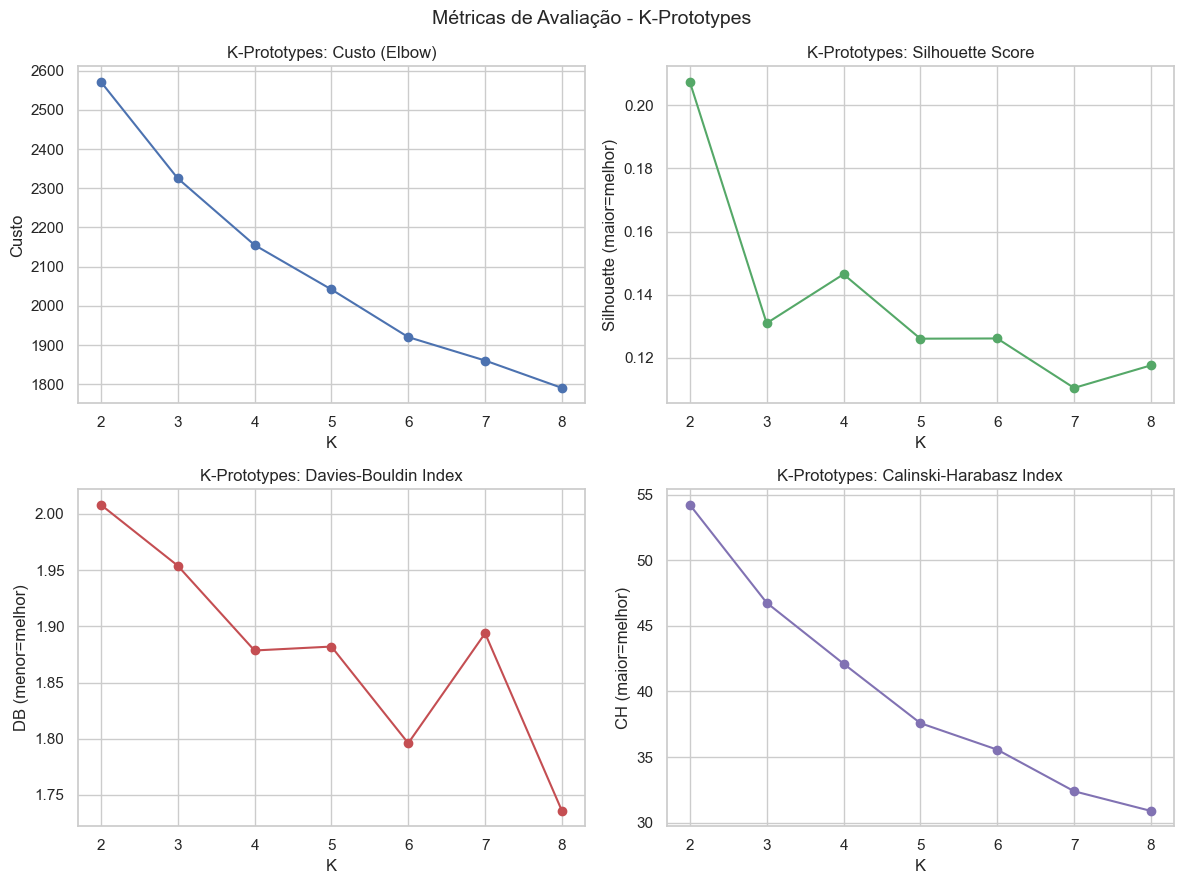

In [6]:
# Visualização das métricas
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].plot(df_kprot_results['k'], df_kprot_results['cost'], 'b-o')
axes[0,0].set_title('K-Prototypes: Custo (Elbow)')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('Custo')

axes[0,1].plot(df_kprot_results['k'], df_kprot_results['silhouette'], 'g-o')
axes[0,1].set_title('K-Prototypes: Silhouette Score')
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('Silhouette (maior=melhor)')

axes[1,0].plot(df_kprot_results['k'], df_kprot_results['davies_bouldin'], 'r-o')
axes[1,0].set_title('K-Prototypes: Davies-Bouldin Index')
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('DB (menor=melhor)')

axes[1,1].plot(df_kprot_results['k'], df_kprot_results['calinski_harabasz'], 'm-o')
axes[1,1].set_title('K-Prototypes: Calinski-Harabasz Index')
axes[1,1].set_xlabel('K'); axes[1,1].set_ylabel('CH (maior=melhor)')

plt.suptitle('Métricas de Avaliação - K-Prototypes', fontsize=14)
plt.tight_layout()
plt.savefig('graficos/kprototypes_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. K-Means: Busca do K ideal (referência)

In [7]:
# One-Hot Encoding para K-Means
X_kmeans_treino = pd.get_dummies(X_treino[vars_entrada], columns=vars_categoricas, drop_first=True)
X_kmeans_teste = pd.get_dummies(X_teste[vars_entrada], columns=vars_categoricas, drop_first=True)

# Alinhar colunas (teste pode não ter todas as categorias)
X_kmeans_teste = X_kmeans_teste.reindex(columns=X_kmeans_treino.columns, fill_value=0)

# Padronizar tudo
scaler_km = StandardScaler()
X_km_treino_scaled = scaler_km.fit_transform(X_kmeans_treino)
X_km_teste_scaled = scaler_km.transform(X_kmeans_teste)

print(f'Shape K-Means treino (após one-hot): {X_km_treino_scaled.shape}')

Shape K-Means treino (após one-hot): (259, 29)


In [8]:
# Busca do K ideal para K-Means
km_results = {'k': [], 'inertia': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels = km.fit_predict(X_km_treino_scaled)
    
    sil = silhouette_score(X_km_treino_scaled, labels)
    db = davies_bouldin_score(X_km_treino_scaled, labels)
    ch = calinski_harabasz_score(X_km_treino_scaled, labels)
    
    km_results['k'].append(k)
    km_results['inertia'].append(km.inertia_)
    km_results['silhouette'].append(sil)
    km_results['davies_bouldin'].append(db)
    km_results['calinski_harabasz'].append(ch)
    
    print(f'K={k}: Inertia={km.inertia_:.2f} | Silhouette={sil:.3f} | DB={db:.3f} | CH={ch:.2f}')

df_km_results = pd.DataFrame(km_results)
print(f'\nMelhor K por Silhouette: {df_km_results.loc[df_km_results["silhouette"].idxmax(), "k"]}')
print(f'Melhor K por Davies-Bouldin: {df_km_results.loc[df_km_results["davies_bouldin"].idxmin(), "k"]}')
print(f'Melhor K por Calinski-Harabasz: {df_km_results.loc[df_km_results["calinski_harabasz"].idxmax(), "k"]}')

K=2: Inertia=6972.07 | Silhouette=0.071 | DB=3.482 | CH=19.87
K=3: Inertia=6590.89 | Silhouette=0.063 | DB=3.117 | CH=17.87
K=4: Inertia=6296.57 | Silhouette=0.100 | DB=2.884 | CH=16.39
K=5: Inertia=6036.41 | Silhouette=0.077 | DB=2.619 | CH=15.51
K=6: Inertia=5746.65 | Silhouette=0.093 | DB=2.400 | CH=15.54
K=7: Inertia=5644.22 | Silhouette=0.067 | DB=2.538 | CH=13.89
K=8: Inertia=5455.56 | Silhouette=0.073 | DB=2.481 | CH=13.51

Melhor K por Silhouette: 4
Melhor K por Davies-Bouldin: 6
Melhor K por Calinski-Harabasz: 2


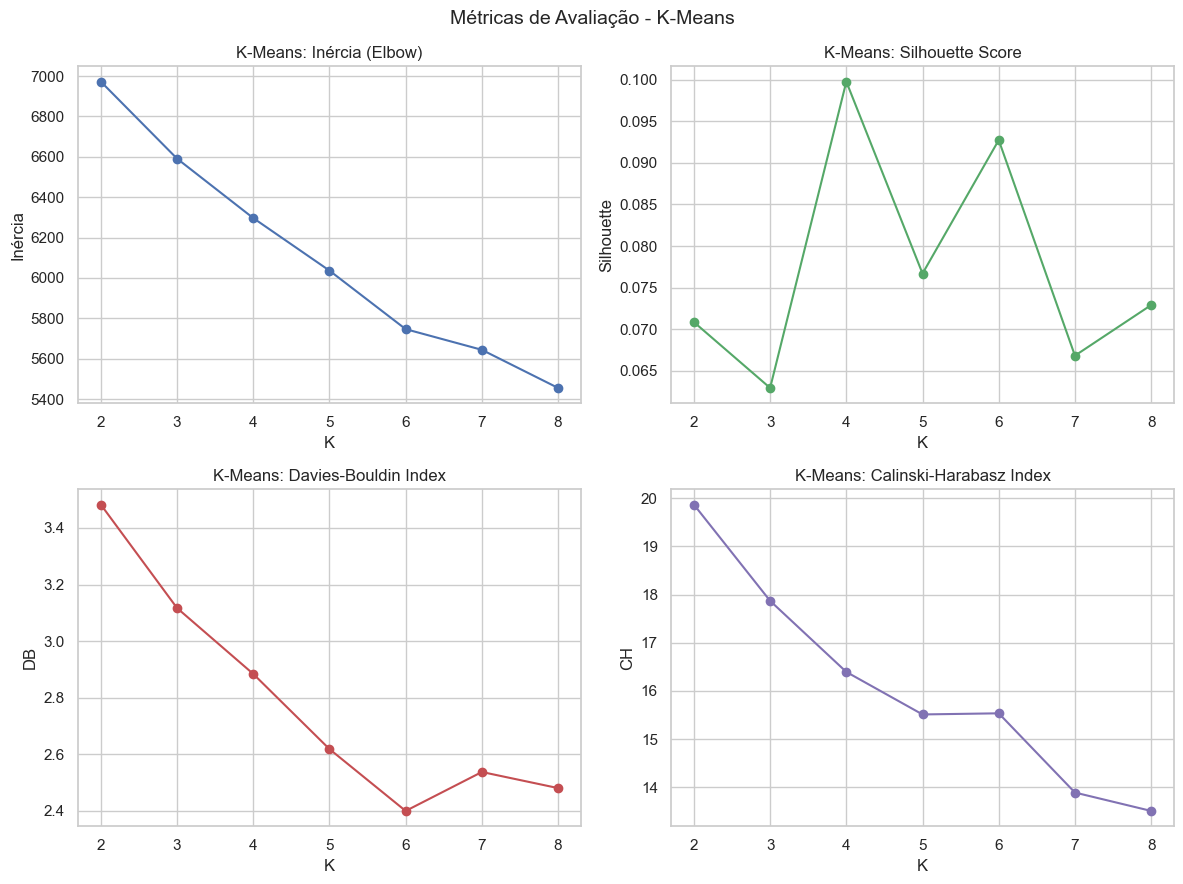

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].plot(df_km_results['k'], df_km_results['inertia'], 'b-o')
axes[0,0].set_title('K-Means: Inércia (Elbow)')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('Inércia')

axes[0,1].plot(df_km_results['k'], df_km_results['silhouette'], 'g-o')
axes[0,1].set_title('K-Means: Silhouette Score')
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('Silhouette')

axes[1,0].plot(df_km_results['k'], df_km_results['davies_bouldin'], 'r-o')
axes[1,0].set_title('K-Means: Davies-Bouldin Index')
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('DB')

axes[1,1].plot(df_km_results['k'], df_km_results['calinski_harabasz'], 'm-o')
axes[1,1].set_title('K-Means: Calinski-Harabasz Index')
axes[1,1].set_xlabel('K'); axes[1,1].set_ylabel('CH')

plt.suptitle('Métricas de Avaliação - K-Means', fontsize=14)
plt.tight_layout()
plt.savefig('graficos/kmeans_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modelo Final e Análise de Perfis

In [10]:
# Selecionar K com base nas métricas (será ajustado após execução)
# Placeholder: usar K que maximize silhouette no K-Prototypes
K_FINAL = int(df_kprot_results.loc[df_kprot_results['silhouette'].idxmax(), 'k'])
print(f'K selecionado: {K_FINAL}')

# Treinar modelo final
kprot_final = KPrototypes(n_clusters=K_FINAL, init='Cao', random_state=RANDOM_STATE, n_init=10, max_iter=100)
labels_treino = kprot_final.fit_predict(X_kprot_treino.values, categorical=cat_indices)

# Adicionar labels ao dataframe de treino
df_treino_perfis = df_treino.copy()
df_treino_perfis['CLUSTER'] = labels_treino

print(f'\nDistribuição dos clusters no treino:')
print(df_treino_perfis['CLUSTER'].value_counts().sort_index())

K selecionado: 2



Distribuição dos clusters no treino:
CLUSTER
0     79
1    180
Name: count, dtype: int64


Desempenho por cluster:


NOTA_3_MAT              NOTA_3_POR              NOTA_1_MAT         \
              mean median   std       mean median   std       mean median   
CLUSTER                                                                     
0             9.30   10.0  3.78      10.95   11.0  3.15       9.66   10.0   
1            10.88   11.0  4.82      13.24   13.0  2.53      11.33   11.0   

              NOTA_1_POR               
          std       mean median   std  
CLUSTER                                
0        2.98      10.87   11.0  2.12  
1        3.36      12.69   13.0  2.36

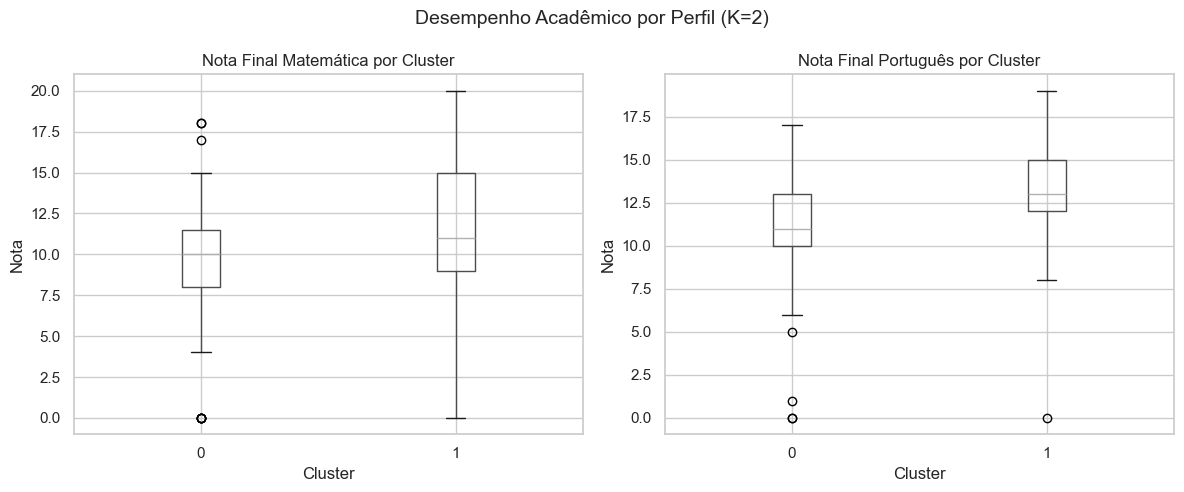

In [11]:
# Cruzar clusters com desempenho (Fator 6)
perfis_desempenho = df_treino_perfis.groupby('CLUSTER')[vars_alvo + ['NOTA_1_MAT', 'NOTA_1_POR']].agg(['mean', 'median', 'std']).round(2)
print('Desempenho por cluster:')
display(perfis_desempenho)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_treino_perfis.boxplot(column='NOTA_3_MAT', by='CLUSTER', ax=axes[0])
axes[0].set_title('Nota Final Matemática por Cluster')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Nota')

df_treino_perfis.boxplot(column='NOTA_3_POR', by='CLUSTER', ax=axes[1])
axes[1].set_title('Nota Final Português por Cluster')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Nota')

plt.suptitle(f'Desempenho Acadêmico por Perfil (K={K_FINAL})', fontsize=14)
plt.tight_layout()
plt.savefig('graficos/perfis_desempenho.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Caracterização dos perfis (variáveis de entrada)
print('Perfil médio de cada cluster (variáveis numéricas):')
perfil_num = df_treino_perfis.groupby('CLUSTER')[vars_numericas].mean().round(2)
display(perfil_num)

# Modas das categóricas por cluster
print('\nModa das variáveis categóricas por cluster:')
perfil_cat = df_treino_perfis.groupby('CLUSTER')[vars_categoricas].agg(lambda x: x.mode()[0])
display(perfil_cat)

Perfil médio de cada cluster (variáveis numéricas):


,ESCOLARIDADE_MAE,ESCOLARIDADE_PAI,QUALIDADE_FAMILIA,TEMPO_ESTUDO_SEMANAL,ALCOOL_DIA_UTIL,ALCOOL_FIM_DE_SEMANA,SAIR_COM_AMIGOS,TEMPO_LIVRE,FALTAS_MAT,FALTAS_POR
CLUSTER,,,,,,,,,,
0,2.96,2.66,3.97,1.63,2.32,3.67,4.16,3.70,9.99,6.54
1,2.64,2.48,3.96,2.18,1.13,1.74,2.76,3.05,3.24,2.44



Moda das variáveis categóricas por cluster:


,PROFISSAO_MAE,PROFISSAO_PAI,SUPORTE_FAMILIAR,STATUS_PAIS,TAMANHO_FAMILIA,SUPORTE_ESCOLAR,AULAS_PAGAS_MAT,AULAS_PAGAS_POR,INTERNET_CASA,ALMEJA_ENSINO_SUPERIOR,RAZAO_ESCOLHA_ESCOLA
CLUSTER,,,,,,,,,,,
0,outro,outro,True,juntos,mais de 3,False,False,False,True,True,curso
1,outro,outro,True,juntos,mais de 3,False,False,False,True,True,curso


## 6. Validação no Hold-Out

In [13]:
# Atribuir clusters ao conjunto de teste
labels_teste = kprot_final.predict(X_kprot_teste.values, categorical=cat_indices)

# Métricas no teste
X_teste_num_array = X_teste_num_scaled.values
sil_teste = silhouette_score(X_teste_num_array, labels_teste)
db_teste = davies_bouldin_score(X_teste_num_array, labels_teste)
ch_teste = calinski_harabasz_score(X_teste_num_array, labels_teste)

# Comparação treino vs teste
sil_treino = silhouette_score(X_treino_num_scaled.values, labels_treino)
db_treino = davies_bouldin_score(X_treino_num_scaled.values, labels_treino)
ch_treino = calinski_harabasz_score(X_treino_num_scaled.values, labels_treino)

print(f'Comparação Treino vs Teste (K={K_FINAL}):')
print(f'{"Métrica":<20} {"Treino":<12} {"Teste":<12}')
print(f'{"Silhouette":<20} {sil_treino:<12.3f} {sil_teste:<12.3f}')
print(f'{"Davies-Bouldin":<20} {db_treino:<12.3f} {db_teste:<12.3f}')
print(f'{"Calinski-Harabasz":<20} {ch_treino:<12.2f} {ch_teste:<12.2f}')

# Distribuição no teste
df_teste_perfis = df_teste.copy()
df_teste_perfis['CLUSTER'] = labels_teste
print(f'\nDistribuição dos clusters no teste:')
print(df_teste_perfis['CLUSTER'].value_counts().sort_index())

# Desempenho no teste por cluster
print(f'\nDesempenho médio por cluster (teste):')
display(df_teste_perfis.groupby('CLUSTER')[vars_alvo].mean().round(2))

Comparação Treino vs Teste (K=2):
Métrica              Treino       Teste       
Silhouette           0.207        0.224       
Davies-Bouldin       2.008        2.121       
Calinski-Harabasz    54.25        19.06       

Distribuição dos clusters no teste:
CLUSTER
0    29
1    82
Name: count, dtype: int64

Desempenho médio por cluster (teste):


,NOTA_3_MAT,NOTA_3_POR
CLUSTER,,
0,11.24,12.03
1,10.40,12.77


## 7. Análise Crítica e Pontos de Atenção

### Diagnóstico do estado atual:

**1. O K=2 encontrou um padrão real, mas talvez simplista demais.**
- Cluster 0 (79 alunos): perfil de maior risco — mais álcool (dia=2.32, fds=3.67), saem mais com amigos (4.16), mais faltas (Mat=10, Por=6.5), menor tempo de estudo (1.63). Notas mais baixas.
- Cluster 1 (180 alunos): perfil engajado — pouco álcool (dia=1.13, fds=1.74), menos social (2.76), poucas faltas (Mat=3.2, Por=2.4), mais estudo (2.18). Notas melhores.
- **Essencialmente separa alunos 'festeiros' de alunos 'dedicados'.** É interpretável, mas raso.

**2. As variáveis categóricas não estão diferenciando os clusters.**
- As modas de TODAS as categóricas são idênticas entre os clusters (outro, outro, True, juntos, mais de 3, False, False, False, True, True, curso).
- Isso significa que os fatores Socioeconômico, Familiar, Recursos e Motivação **não contribuíram** para a separação.
- A clusterização está sendo dominada pelas variáveis comportamentais (álcool, faltas, saídas).

**3. Silhouette de 0.207 é baixo, mas aceitável para dados sociais.**
- Valores acima de 0.5 são raros em dados socioeconômicos reais.
- A consistência treino (0.207) vs teste (0.224) é um bom sinal de generalização.

**4. CH no teste (19.06) vs treino (54.25) — queda grande.**
- Calinski-Harabasz é sensível ao tamanho da amostra (111 vs 259). Queda esperada.
- Não indica necessariamente overfitting.

**5. Desempenho no teste inverteu levemente (Cluster 0: Mat=11.24 vs Cluster 1: Mat=10.40).**
- No treino, Cluster 1 tinha notas maiores. No teste, inverteu em Mat.
- Pode indicar instabilidade dos clusters com poucos dados, ou que os perfis não são tão robustos.

---

### Recomendações (DISCUTIR COM O GRUPO):

**A) Testar K=3 ou K=4 mesmo com silhouette menor.**
- K=4 teve silhouette 0.146 (vs 0.207 para K=2). A perda é pequena.
- Pode revelar subperfis mais ricos (ex: separar 'dedicado com suporte' de 'dedicado sem suporte').
- Para o relatório, perfis mais descritivos geram uma discussão melhor.

**B) Considerar remover variáveis categóricas com variância zero entre clusters.**
- Se ALMEJA_ENSINO_SUPERIOR é 96.6% True, não discrimina nada. Remover.
- Se as profissões são sempre 'outro', não ajudam. Remover ou agrupar.
- Reexecutar com subset limpo pode melhorar a separação.

**C) Explorar gamma (peso relativo cat/num) no K-Prototypes.**
- O parâmetro gamma controla quanto peso as categóricas têm vs numéricas.
- Default pode estar dando peso demais às categóricas sem variância.

**D) Adicionar PCA 2D para visualização.**
- Plotar os pontos coloridos por cluster em 2D ajuda muito no relatório.
- Mostra visualmente a separação (ou falta dela).

**E) No relatório, a narrativa deve ser honesta:**
- 'Os clusters encontrados refletem primariamente diferenças comportamentais (álcool, absenteísmo, socialização), com fatores socioeconômicos e familiares contribuindo marginalmente.'
- Isso é um resultado válido — mostra que o comportamento é mais determinante que a origem social para este dataset.